In [3]:
import pandas as pd

df = pd.read_csv('/Users/sakshamkapoor/Downloads/ML-Summer_training/classification_streamlit/healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
# data information gathering
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
# Data Cleaning
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# drop column ID
df.drop("id", axis = 1 , inplace = True)

In [12]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [13]:
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [14]:
df.to_csv("/Users/sakshamkapoor/Downloads/ML-Summer_training/stoke_prediction_cleaned.csv", index=False)

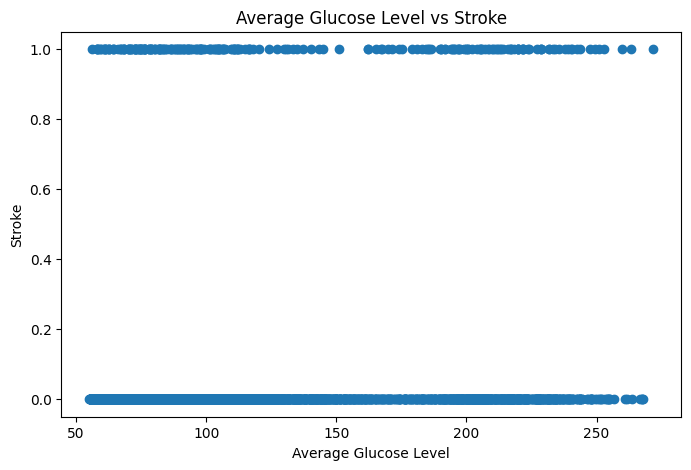

In [15]:
# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(df["avg_glucose_level"], df["stroke"])
plt.xlabel("Average Glucose Level")
plt.ylabel("Stroke")
plt.title("Average Glucose Level vs Stroke")
plt.show()

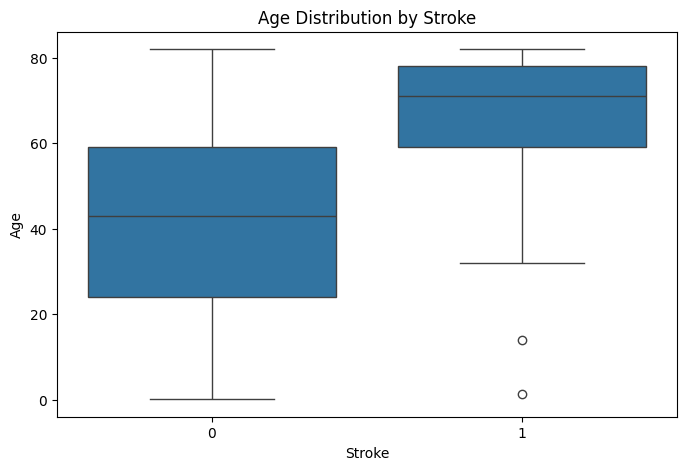

In [16]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x="stroke", y="age", data=df)

plt.xlabel("Stroke")
plt.ylabel("Age")
plt.title("Age Distribution by Stroke")
plt.show()

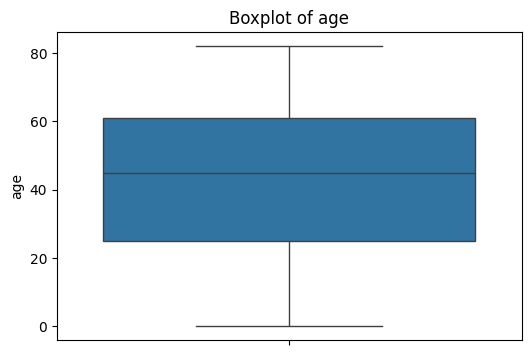

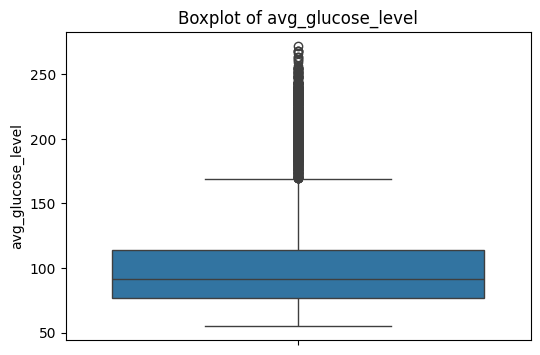

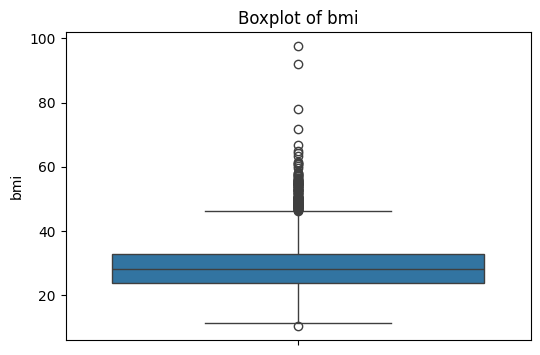

In [17]:
num_cols = ["age", "avg_glucose_level", "bmi"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

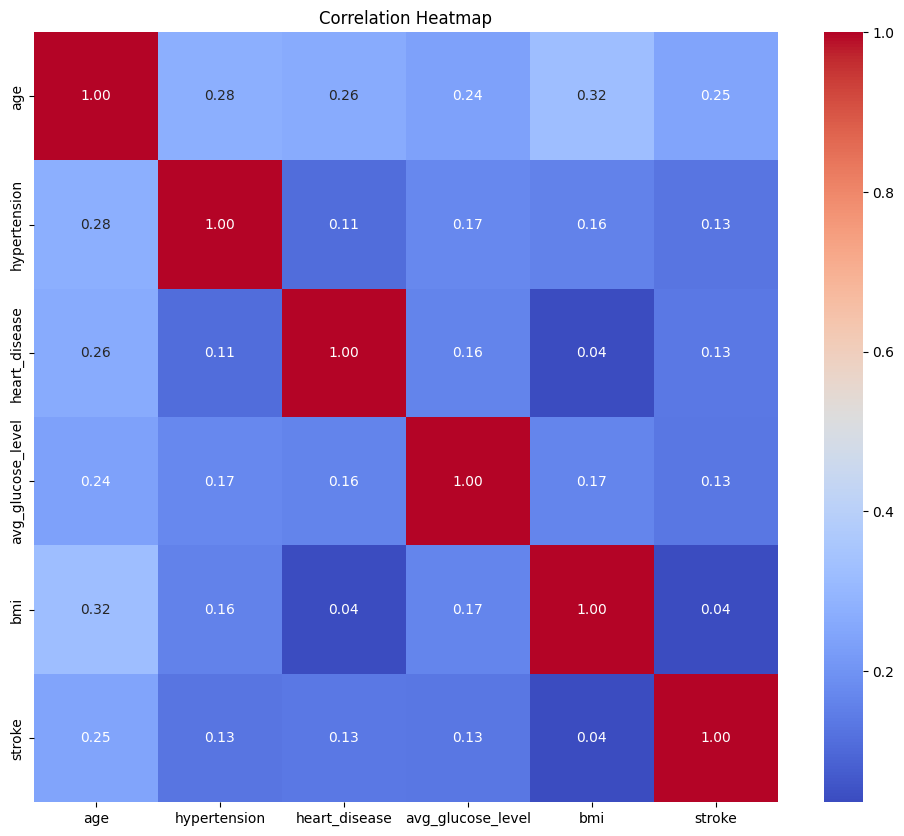

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot correlation heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
df_original = df.copy()

In [20]:
# check categorical columns 
df.select_dtypes(include = "object").columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

In [21]:
df = pd.get_dummies(df,drop_first = True)

In [22]:
# X and y split
X = df.drop("stroke", axis = 1)
y = df["stroke"]

In [23]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
sample = [
    [67, 0, 1, 228.69, 36.6, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [45, 1, 0, 150.20, 29.8, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [30, 0, 0, 95.40, 23.5, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1]
]

sample = pd.DataFrame(sample, columns=X_train.columns)

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Classification_DT = DecisionTreeClassifier()

Classification_DT.fit(X_train, y_train)

y_pred = Classification_DT.predict(X_test)

S_DT = accuracy_score(y_test, y_pred)

DT_P1 = Classification_DT.predict(sample.iloc[[0]])
DT_P2 = Classification_DT.predict(sample.iloc[[1]])
DT_P3 = Classification_DT.predict(sample.iloc[[2]])

print(DT_P1)
print(DT_P2)
print(DT_P3)

print("Accuracy Score:", S_DT)

[1]
[0]
[0]
Accuracy Score: 0.9050880626223092


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Classification_RF = RandomForestClassifier()

Classification_RF.fit(X_train, y_train)

y_pred = Classification_RF.predict(X_test)

S_RF = accuracy_score(y_test, y_pred)

RF_P1 = Classification_RF.predict(sample.iloc[[0]])
RF_P2 = Classification_RF.predict(sample.iloc[[1]])
RF_P3 = Classification_RF.predict(sample.iloc[[2]])

print(RF_P1)
print(RF_P2)
print(RF_P3)

print("Accuracy Score:", S_RF)

[0]
[0]
[0]
Accuracy Score: 0.9393346379647749


In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

Classification_KNN = KNeighborsClassifier()

Classification_KNN.fit(X_train, y_train)

y_pred = Classification_KNN.predict(X_test)

S_KNN = accuracy_score(y_test, y_pred)

KNN_P1 = Classification_KNN.predict(sample.iloc[[0]])
KNN_P2 = Classification_KNN.predict(sample.iloc[[1]])
KNN_P3 = Classification_KNN.predict(sample.iloc[[2]])

print(KNN_P1)
print(KNN_P2)
print(KNN_P3)

print("Accuracy Score:", S_KNN)

[0]
[0]
[0]
Accuracy Score: 0.9373776908023483


In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

Classifier_SVC = SVC()

Classifier_SVC.fit(X_train, y_train)

y_pred = Classifier_SVC.predict(X_test)

S_SVC = accuracy_score(y_test, y_pred)

SVC_P1 = Classifier_SVC.predict(sample.iloc[[0]])
SVC_P2 = Classifier_SVC.predict(sample.iloc[[1]])
SVC_P3 = Classifier_SVC.predict(sample.iloc[[2]])

print(SVC_P1)
print(SVC_P2)
print(SVC_P3)

print("Accuracy Score:", S_SVC)

[0]
[0]
[0]
Accuracy Score: 0.9393346379647749


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Classification_LR = LogisticRegression()

Classification_LR.fit(X_train, y_train)

y_pred = Classification_LR.predict(X_test)

S_LR = accuracy_score(y_test, y_pred)

LR_P1 = Classification_LR.predict(sample.iloc[[0]])
LR_P2 = Classification_LR.predict(sample.iloc[[1]])
LR_P3 = Classification_LR.predict(sample.iloc[[2]])

print(LR_P1)
print(LR_P2)
print(LR_P3)

print("Accuracy Score:", S_LR)

[0]
[0]
[0]
Accuracy Score: 0.9393346379647749


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

Classification_GB = GradientBoostingClassifier()

Classification_GB.fit(X_train, y_train)

y_pred = Classification_GB.predict(X_test)

S_GB = accuracy_score(y_test, y_pred)

GB_P1 = Classification_GB.predict(sample.iloc[[0]])
GB_P2 = Classification_GB.predict(sample.iloc[[1]])
GB_P3 = Classification_GB.predict(sample.iloc[[2]])

print(GB_P1)
print(GB_P2)
print(GB_P3)

print("Accuracy Score:", S_GB)

[0]
[0]
[0]
Accuracy Score: 0.9403131115459883


In [32]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

Classification_NB = GaussianNB()

Classification_NB.fit(X_train, y_train)

y_pred = Classification_NB.predict(X_test)

S_NB = accuracy_score(y_test, y_pred)

NB_P1 = Classification_NB.predict(sample.iloc[[0]])
NB_P2 = Classification_NB.predict(sample.iloc[[1]])
NB_P3 = Classification_NB.predict(sample.iloc[[2]])

print(NB_P1)
print(NB_P2)
print(NB_P3)

print("Accuracy Score:", S_NB)

[1]
[1]
[0]
Accuracy Score: 0.5459882583170255


In [33]:
a = pd.DataFrame({
    'Algorithm': ['Logistic Regression',
                  'Decision Tree',
                  'Random Forest',
                  'SVM',
                  'Naive Bayes',
                  'KNN',
                  'Gradient Boosting'],

    'AccuracyScore': [S_LR, S_DT, S_RF, S_SVC, S_NB, S_KNN, S_GB],

    'Input1': ['67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0']*7,
    'Input2': ['45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0']*7,
    'Input3': ['30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1']*7,

    'Prediction1': [LR_P1, DT_P1, RF_P1, SVC_P1, NB_P1, KNN_P1, GB_P1],
    'Prediction2': [LR_P2, DT_P2, RF_P2, SVC_P2, NB_P2, KNN_P2, GB_P2],
    'Prediction3': [LR_P3, DT_P3, RF_P3, SVC_P3, NB_P3, KNN_P3, GB_P3]
})

a

,Algorithm,AccuracyScore,Input1,Input2,Input3,Prediction1,Prediction2,Prediction3
0,Logistic Regression,0.939335,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[0],[0],[0]
1,Decision Tree,0.905088,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[1],[0],[0]
2,Random Forest,0.939335,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[0],[0],[0]
3,SVM,0.939335,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[0],[0],[0]
4,Naive Bayes,0.545988,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[1],[1],[0]
5,KNN,0.937378,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[0],[0],[0]
6,Gradient Boosting,0.940313,"67,0,1,228.69,36.6,1,0,1,0,1,0,0,1,0,1,0","45,1,0,150.20,29.8,0,0,1,0,0,1,0,0,1,0,0","30,0,0,95.40,23.5,1,0,0,0,1,0,0,1,0,0,1",[0],[0],[0]


In [34]:
import joblib

# Save the trained Gradient Boosting model
joblib.dump(Classification_GB, "gradient_boosting_model.pkl")

# Save the feature order
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!
